## Forecasting Noisy Financial Data with Regularized Regression
#### I plan to demonstrate how simple regression models behave on noisy financial series data and how **(L1/L2) penalties** can help in **regularization** if the model were to **overfit**, I'll first prepare the data, then fit **baseline models (OLS and ARIMA)**, and then show **Ridge** (L2) and **Lasso** (L1) regression (and e-net as well). And then we evaluate using rolling-origin cross validation which is a time series-specific technique used to evaluate forecasting models.



In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

plt.style.use("seaborn-v0_8")


In [37]:
# we simulate a noisy price series
np.random.seed(0)
dates = pd.date_range("2020-01-01", periods=600, freq="D")
price = 100 + np.cumsum(np.random.randn(len(dates))) # cumulative sum of noise
data = pd.DataFrame({"Price": price}, index=dates)
data.head()

,Price
2020-01-01,101.764052
2020-01-02,102.164210
2020-01-03,103.142948
2020-01-04,105.383841
2020-01-05,107.251399


In [38]:
data["LogRet"] = np.log(data["Price"] / data["Price"].shift(1))
data = data.dropna()

# last 50 days' returns
MAX_LAG = 50
for lag in range(1, MAX_LAG + 1):
    data[f"Lag_{lag}"] = data["LogRet"].shift(lag)

data = data.dropna()
data.head()

,Price,LogRet,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,...,Lag_41,Lag_42,Lag_43,Lag_44,Lag_45,Lag_46,Lag_47,Lag_48,Lag_49,Lag_50
2020-02-21,106.519400,0.003639,-0.008402,-0.001986,-0.014937,0.007168,-0.011525,-0.003999,-0.004632,0.017848,...,0.001341,0.003831,-0.000964,-0.001413,0.008900,-0.009154,0.017566,0.021493,0.009534,0.003924
2020-02-22,106.008594,-0.004807,0.003639,-0.008402,-0.001986,-0.014937,0.007168,-0.011525,-0.003999,-0.004632,...,0.013434,0.001341,0.003831,-0.000964,-0.001413,0.008900,-0.009154,0.017566,0.021493,0.009534
2020-02-23,104.827962,-0.011200,-0.004807,0.003639,-0.008402,-0.001986,-0.014937,0.007168,-0.011525,-0.003999,...,0.006959,0.013434,0.001341,0.003831,-0.000964,-0.001413,0.008900,-0.009154,0.017566,0.021493
2020-02-24,104.799780,-0.000269,-0.011200,-0.004807,0.003639,-0.008402,-0.001986,-0.014937,0.007168,-0.011525,...,0.001108,0.006959,0.013434,0.001341,0.003831,-0.000964,-0.001413,0.008900,-0.009154,0.017566
2020-02-25,105.228112,0.004079,-0.000269,-0.011200,-0.004807,0.003639,-0.008402,-0.001986,-0.014937,0.007168,...,0.004032,0.001108,0.006959,0.013434,0.001341,0.003831,-0.000964,-0.001413,0.008900,-0.009154


In [ ]:
# train test split
split = int(len(data) * 0.25)
train = data.iloc[:split]
test = data.iloc[split:]

## **Noise injection**
#### To simulate market microstructure noise or measurement errors, we add noise **only to the training target**.
#### This creates patterns that an over-parameterized model may or may not memorize.


In [21]:
noise = 0.02 * np.random.randn(len(train))

y_train = train["LogRet"].values + noise
y_test  = test["LogRet"].values

X_train = train.filter(like="Lag_").values
X_test  = test.filter(like="Lag_").values

##### Feature scaling:

In [24]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## Baseline Models (OLS and ARIMA)
## We fit a simple Ordinary Least Squares (OLS) linear regression using the lagged returns as predictors. 

 #### In noisy financial series, OLS coefficients can become large and volatile. This often leads to overfitting, as the model tries to explain random fluctuations. Below, I will demonstrate how regularization will help

In [26]:
ols = LinearRegression()
ols.fit(X_train, y_train)

train_pred_ols = ols.predict(X_train)
test_pred_ols  = ols.predict(X_test)

train_mse_ols = np.mean((y_train - train_pred_ols)**2)
test_mse_ols  = np.mean((y_test  - test_pred_ols)**2)

print(f"OLS Train MSE: {train_mse_ols:.4e}")
print(f"OLS Test  MSE: {test_mse_ols:.4e}")

OLS Train MSE: 2.8910e-04
OLS Test  MSE: 4.8707e-04


## Regularization: **Ridge (L2)** and **Lasso (L1)** and **ElasticNet**

##### Now I'll add regularization to stabilize the regression. **Ridge** regression adds an L2 penalty on the coefficient magnitudes, which shrinks them towards zero. **Lasso** regression adds an L1 penalty, which can shrink some coefficients all the way to zero. I also consider **ElasticNet**, which blends L1 and L2 penalties.


In [27]:
models = {
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=0.05),
    "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = np.mean((y_test - pred)**2)
    print(f"{name} Test MSE: {mse:.4e}")

Ridge Test MSE: 3.9302e-04
Lasso Test MSE: 1.2155e-04
ElasticNet Test MSE: 1.2155e-04


In [28]:
print("OLS coefficient norm:", np.linalg.norm(ols.coef_))
print("Ridge coefficient norm:", np.linalg.norm(models["Ridge"].coef_))
print("Lasso nonzero coefficients:", np.sum(models["Lasso"].coef_ != 0))

OLS coefficient norm: 0.016256738861352864
Ridge coefficient norm: 0.013824241533120209
Lasso nonzero coefficients: 0


#### Now I sweep different values of alpha and observe test error.

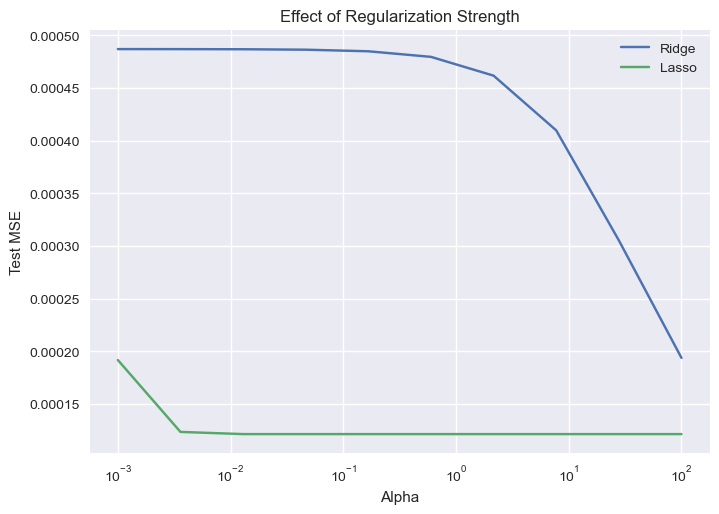

In [29]:
alphas = np.logspace(-3, 2, 10)

ridge_mse = []
lasso_mse = []

for a in alphas:
    ridge_mse.append(
        np.mean((y_test - Ridge(alpha=a).fit(X_train, y_train).predict(X_test))**2)
    )
    lasso_mse.append(
        np.mean((y_test - Lasso(alpha=a).fit(X_train, y_train).predict(X_test))**2)
    )

plt.plot(alphas, ridge_mse, label="Ridge")
plt.plot(alphas, lasso_mse, label="Lasso")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Test MSE")
plt.title("Effect of Regularization Strength")
plt.legend()
plt.show()


In [31]:
y_train_ts = train["LogRet"]
y_test_ts  = test["LogRet"]


In [32]:
ar5  = ARIMA(y_train_ts, order=(5,0,0)).fit()
ar30 = ARIMA(y_train_ts, order=(30,0,0)).fit()

pred_ar5  = ar5.predict(start=y_test_ts.index[0], end=y_test_ts.index[-1])
pred_ar30 = ar30.predict(start=y_test_ts.index[0], end=y_test_ts.index[-1])

mse_ar5  = np.mean((y_test_ts - pred_ar5)**2)
mse_ar30 = np.mean((y_test_ts - pred_ar30)**2)

print(f"AR(5)  Test MSE: {mse_ar5:.4e}")
print(f"AR(30) Test MSE: {mse_ar30:.4e}")

c:\Users\ther0\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AR(5)  Test MSE: 1.2259e-04
AR(30) Test MSE: 1.2195e-04


c:\Users\ther0\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ther0\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ther0\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ther0\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


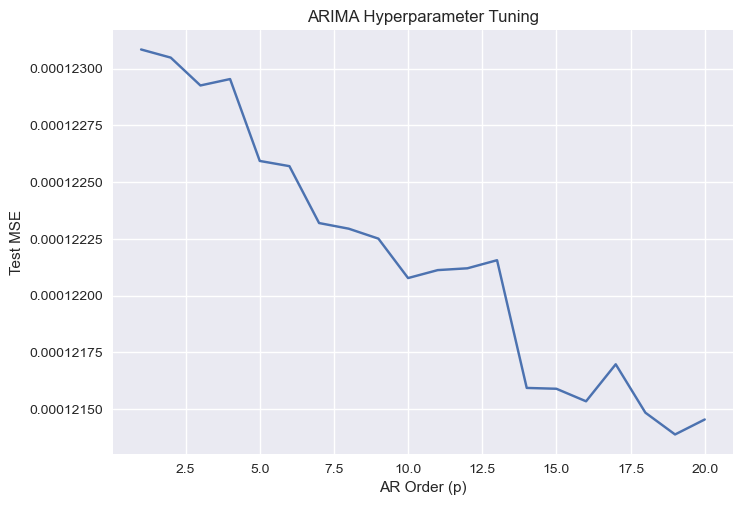

In [33]:
orders = range(1, 21)
arima_mse = []

for p in orders:
    try:
        model = ARIMA(y_train_ts, order=(p,0,0)).fit()
        pred = model.predict(start=y_test_ts.index[0], end=y_test_ts.index[-1])
        mse = np.mean((y_test_ts - pred)**2)
        arima_mse.append(mse)
    except:
        arima_mse.append(np.nan)

plt.plot(orders, arima_mse)
plt.xlabel("AR Order (p)")
plt.ylabel("Test MSE")
plt.title("ARIMA Hyperparameter Tuning")
plt.show()